## Plotting bars of the trap weights for paper

Importing the data:

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

# load data
spring = pd.read_csv('../../sediment_traps/trap_weights/spring_trap_weights.csv')
summer = pd.read_csv('../../sediment_traps/trap_weights/summer_trap_weights.csv')

Formatting the data set for sns to use

In [ ]:
def _find_col(df, includes):
    for c in df.columns:
        c_norm = c.strip().lower()
        if any(token in c_norm for token in includes):
            return c
    return None

def _legacy_extract(df, size_label):
    out = (
        df[df['Size'].isin([size_label])]
        .melt(id_vars='Size', var_name='Sample', value_name='Weight')
    )
    out['Sample'] = out['Sample'].astype(str).str.strip()
    out['Weight'] = pd.to_numeric(out['Weight'], errors='coerce')
    return out.reset_index(drop=True)

def _current_extract(df, size_label, weight_col, sample_col):
    out = pd.DataFrame({
        'Size': size_label,
        'Sample': df[sample_col].astype(str).str.strip(),
        'Weight': pd.to_numeric(df[weight_col], errors='coerce')
    })
    return out.reset_index(drop=True)

def _build_weight_tables(df):
    if 'Size' in df.columns:
        return {
            'weights': _legacy_extract(df, 'WEIGHTLISST'),
            'CS': _legacy_extract(df, 'COARSESAND'),
            'FS': _legacy_extract(df, 'FINESAND'),
            'S': _legacy_extract(df, 'SILT'),
            'C': _legacy_extract(df, 'CLAY')
        }
    sample_col = _find_col(df, ['trap', 'sample'])
    total_col = _find_col(df, ['total'])
    coarse_col = _find_col(df, ['coarse'])
    fine_col = _find_col(df, ['fine'])
    silt_col = _find_col(df, ['silt'])
    clay_col = _find_col(df, ['clay'])

    missing = [name for name, col in {
        'sample': sample_col,
        'total': total_col,
        'coarse': coarse_col,
        'fine': fine_col,
        'silt': silt_col,
        'clay': clay_col
    }.items() if col is None]
    if missing:
        raise ValueError(f"Missing expected column(s) in current-format table: {missing}")

    return {
        'weights': _current_extract(df, 'WEIGHTLISST', total_col, sample_col),
        'CS': _current_extract(df, 'COARSESAND', coarse_col, sample_col),
        'FS': _current_extract(df, 'FINESAND', fine_col, sample_col),
        'S': _current_extract(df, 'SILT', silt_col, sample_col),
        'C': _current_extract(df, 'CLAY', clay_col, sample_col)
    }

spring_tables = _build_weight_tables(spring)
summer_tables = _build_weight_tables(summer)

# Keep variable names expected by downstream cells.
spring_weights = spring_tables['weights']
summer_weights = summer_tables['weights']
spring_CS = spring_tables['CS']
summer_CS = summer_tables['CS']
spring_FS = spring_tables['FS']
summer_FS = summer_tables['FS']
spring_S = spring_tables['S']
summer_S = summer_tables['S']
spring_C = spring_tables['C']
summer_C = summer_tables['C']

In [3]:
# function to determine if the sample is open or closed
def determine_type(sample_id):
    if sample_id.endswith(('B', 'C')):
        return 'open'
    elif sample_id.endswith(('A', 'D')):
        return 'closed'
    else:
        return 'unknown'  

# apply the function to create a new column
spring_CS['Type'] = spring_CS['Sample'].apply(determine_type)
summer_CS['Type'] = summer_CS['Sample'].apply(determine_type)
spring_FS['Type'] = spring_FS['Sample'].apply(determine_type)
summer_FS['Type'] = summer_FS['Sample'].apply(determine_type)
spring_S['Type'] = spring_S['Sample'].apply(determine_type)
summer_S['Type'] = summer_S['Sample'].apply(determine_type)
spring_C['Type'] = spring_C['Sample'].apply(determine_type)
summer_C['Type'] = summer_C['Sample'].apply(determine_type)

## Bar Plots

Total Sediment

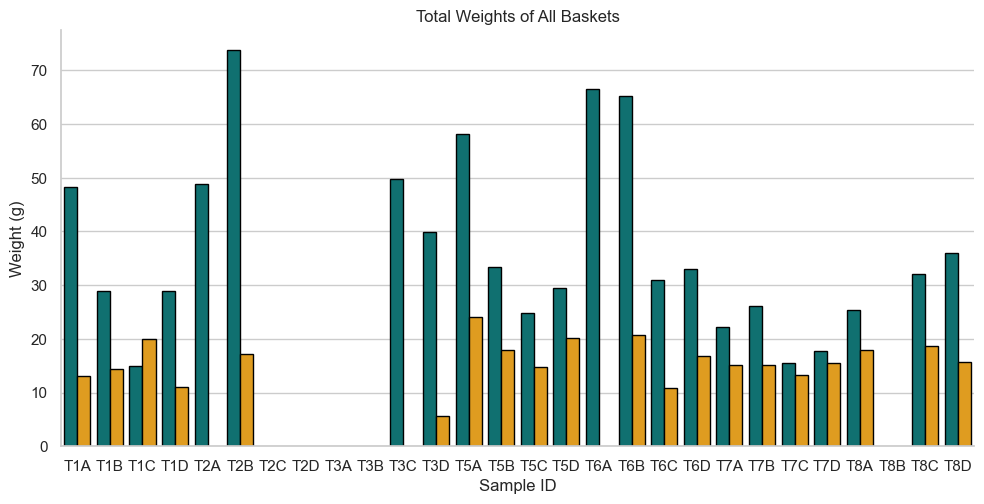

In [ ]:
# add a new column to indicate the season
spring_weights['season'] = 'Spring'
summer_weights['season'] = 'Summer'

# concatenate the two dataframes
weights = pd.concat([spring_weights, summer_weights], ignore_index=True)
weights['Type'] = weights['Sample'].apply(determine_type)

# create the bar plot with custom colors and alpha value for teal
sns.set_theme(style="whitegrid")
g = sns.catplot(data=weights, x='Sample', y='Weight', hue='season', kind='bar',
                height=5, aspect=2, palette={'Spring': 'teal', 'Summer': 'orange'}, legend=False, edgecolor='black')
plt.title('Total Weights of All Baskets')
plt.xlabel('Sample ID')
plt.ylabel('Weight (g)')
plt.show()

Coarse Sand

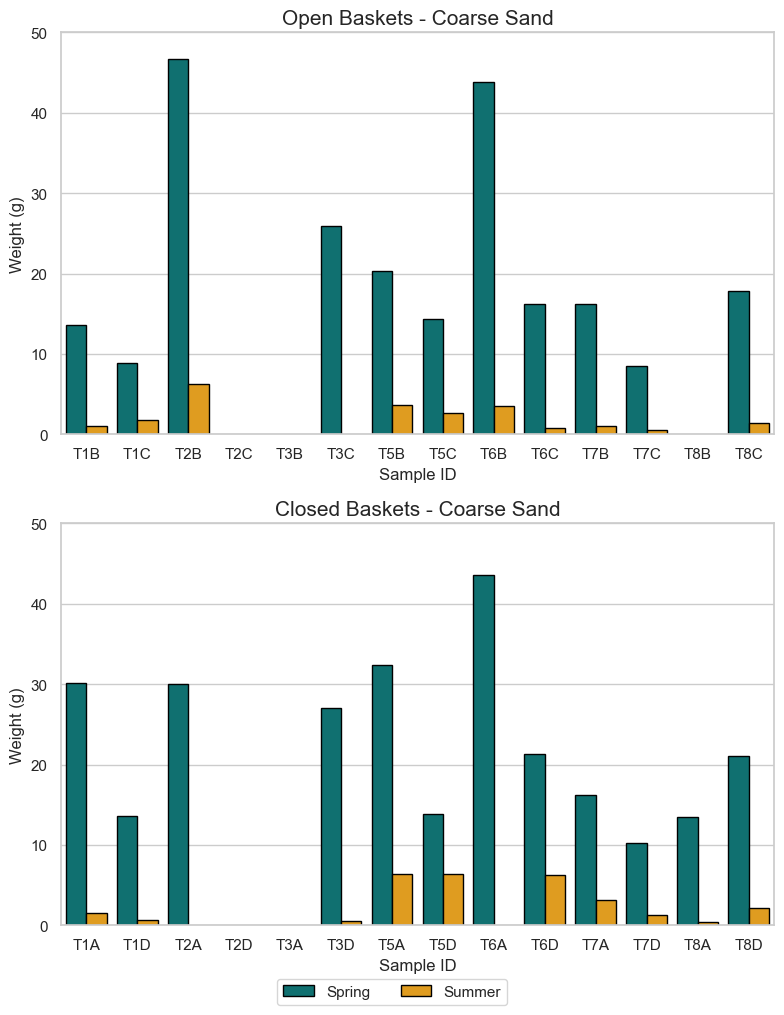

In [10]:
# add a new column to indicate the season
spring_CS['season'] = 'Spring'
summer_CS['season'] = 'Summer'

# concatenate the two dataframes
weights = pd.concat([spring_CS, summer_CS], ignore_index=True)

# separate the dataframes based on the type of trap
open_CS = weights[weights['Type'] == 'open']
closed_CS = weights[weights['Type'] == 'closed']

# create open and closed bar plots using subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 10))
sns.set_theme(style="whitegrid")

# open baskets
sns.barplot(data=open_CS, x='Sample', y='Weight', hue='season', 
            ax=axs[0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0].set_title('Open Baskets - Coarse Sand', size=15)
axs[0].set_ylabel('Weight (g)')
axs[0].set_xlabel('Sample ID')
axs[0].set_ylim(0, 50)
axs[0].legend_.remove()  # remove the individual legend for open baskets

# closed baskets
sns.barplot(data=closed_CS, x='Sample', y='Weight', hue='season', 
            ax=axs[1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1].set_title('Closed Baskets - Coarse Sand', size=15)
axs[1].set_ylabel('Weight (g)')
axs[1].set_xlabel('Sample ID')
axs[1].set_ylim(0, 50)
axs[1].legend_.remove()  # remove the individual legend for closed baskets

# add a single legend for both plots
handles, labels = axs[0].get_legend_handles_labels()  # get legend info from the first plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

# adjust layout and save the figure
plt.tight_layout()  # Leave space for the legend at the bottom
plt.show()

Fine Sand

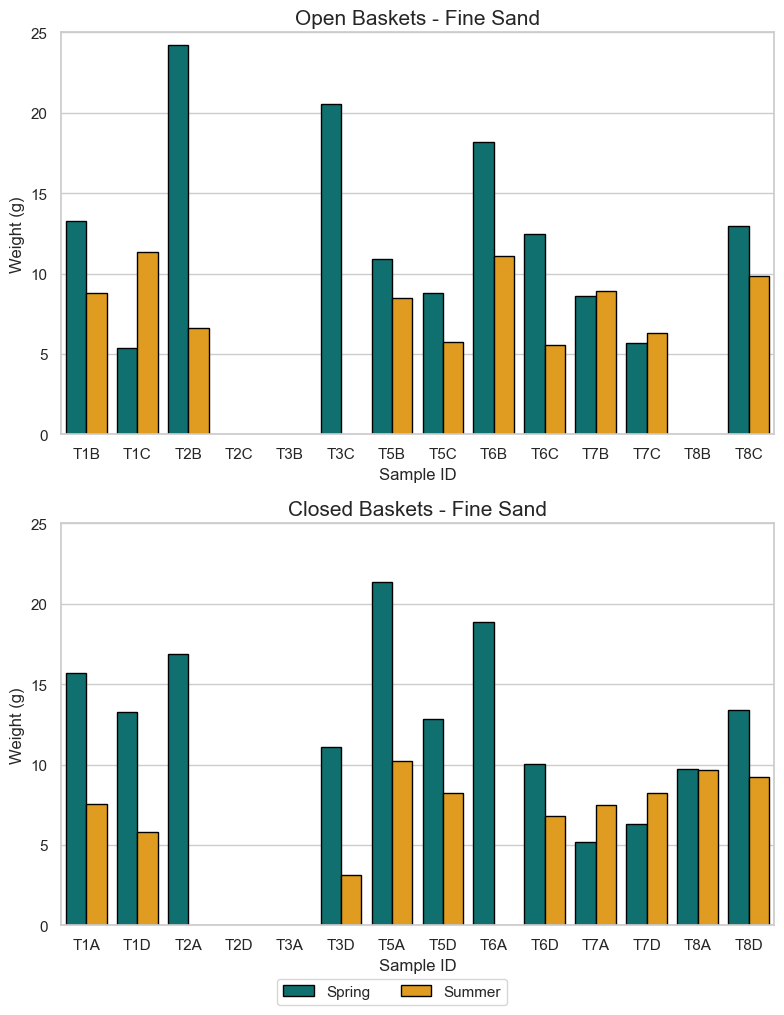

In [14]:
# add a new column to indicate the season
spring_FS['season'] = 'Spring'
summer_FS['season'] = 'Summer'

# concatenate the two dataframes
weights = pd.concat([spring_FS, summer_FS], ignore_index=True)

# separate the dataframes based on the type of trap
open_FS = weights[weights['Type'] == 'open']
closed_FS = weights[weights['Type'] == 'closed']

# create open and closed bar plots using subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 10))
sns.set_theme(style="whitegrid")

# open baskets
sns.barplot(data=open_FS, x='Sample', y='Weight', hue='season', 
            ax=axs[0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0].set_title('Open Baskets - Fine Sand', size=15)
axs[0].set_ylabel('Weight (g)')
axs[0].set_xlabel('Sample ID')
axs[0].set_ylim(0, 25)
axs[0].legend_.remove()  # remove the individual legend for open baskets

# closed baskets
sns.barplot(data=closed_FS, x='Sample', y='Weight', hue='season', 
            ax=axs[1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1].set_title('Closed Baskets - Fine Sand', size=15)
axs[1].set_ylabel('Weight (g)')
axs[1].set_xlabel('Sample ID')
axs[1].set_ylim(0, 25)
axs[1].legend_.remove()  # remove the individual legend for closed baskets

# add a single legend for both plots
handles, labels = axs[0].get_legend_handles_labels()  # get legend info from the first plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

# adjust layout and save the figure
plt.tight_layout()  # Leave space for the legend at the bottom
plt.show()

Silt

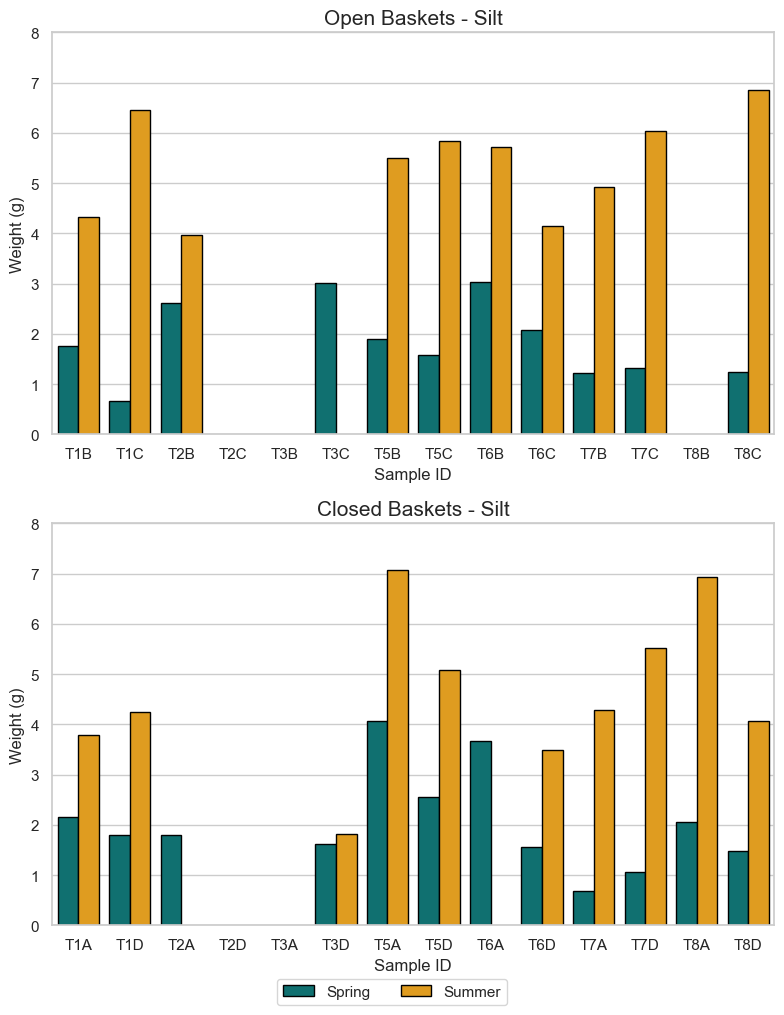

In [18]:
# add a new column to indicate the season
spring_S['season'] = 'Spring'
summer_S['season'] = 'Summer'

# concatenate the two dataframes
weights = pd.concat([spring_S, summer_S], ignore_index=True)

# separate the dataframes based on the type of trap
open_S = weights[weights['Type'] == 'open']
closed_S = weights[weights['Type'] == 'closed']

# create open and closed bar plots using subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 10))
sns.set_theme(style="whitegrid")

# open baskets
sns.barplot(data=open_S, x='Sample', y='Weight', hue='season', 
            ax=axs[0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0].set_title('Open Baskets - Silt', size=15)
axs[0].set_ylabel('Weight (g)')
axs[0].set_xlabel('Sample ID')
axs[0].set_ylim(0, 8)
axs[0].legend_.remove()  # remove the individual legend for open baskets

# closed baskets
sns.barplot(data=closed_S, x='Sample', y='Weight', hue='season', 
            ax=axs[1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1].set_title('Closed Baskets - Silt', size=15)
axs[1].set_ylabel('Weight (g)')
axs[1].set_xlabel('Sample ID')
axs[1].set_ylim(0, 8)
axs[1].legend_.remove()  # remove the individual legend for closed baskets

# add a single legend for both plots
handles, labels = axs[0].get_legend_handles_labels()  # get legend info from the first plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

# adjust layout and save the figure
plt.tight_layout()  # Leave space for the legend at the bottom
plt.show()

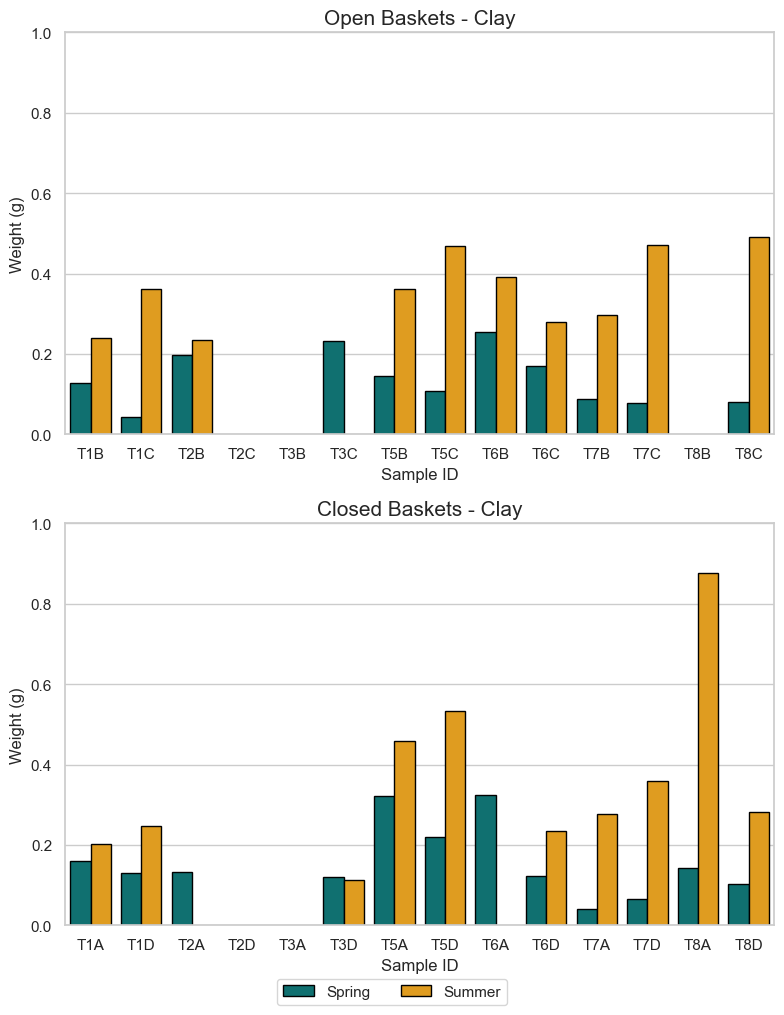

In [19]:
# add a new column to indicate the season
spring_C['season'] = 'Spring'
summer_C['season'] = 'Summer'

# concatenate the two dataframes
weights = pd.concat([spring_C, summer_C], ignore_index=True)

# separate the dataframes based on the type of trap
open_C = weights[weights['Type'] == 'open']
closed_C = weights[weights['Type'] == 'closed']

# create open and closed bar plots using subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 10))
sns.set_theme(style="whitegrid")

# open baskets
sns.barplot(data=open_C, x='Sample', y='Weight', hue='season', 
            ax=axs[0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0].set_title('Open Baskets - Clay', size=15)
axs[0].set_ylabel('Weight (g)')
axs[0].set_xlabel('Sample ID')
axs[0].set_ylim(0, 1)
axs[0].legend_.remove()  # remove the individual legend for open baskets

# closed baskets
sns.barplot(data=closed_C, x='Sample', y='Weight', hue='season', 
            ax=axs[1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1].set_title('Closed Baskets - Clay', size=15)
axs[1].set_ylabel('Weight (g)')
axs[1].set_xlabel('Sample ID')
axs[1].set_ylim(0, 1)
axs[1].legend_.remove()  # remove the individual legend for closed baskets

# add a single legend for both plots
handles, labels = axs[0].get_legend_handles_labels()  # get legend info from the first plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

# adjust layout and save the figure
plt.tight_layout()  # Leave space for the legend at the bottom
plt.show()

Massive Composite Plot

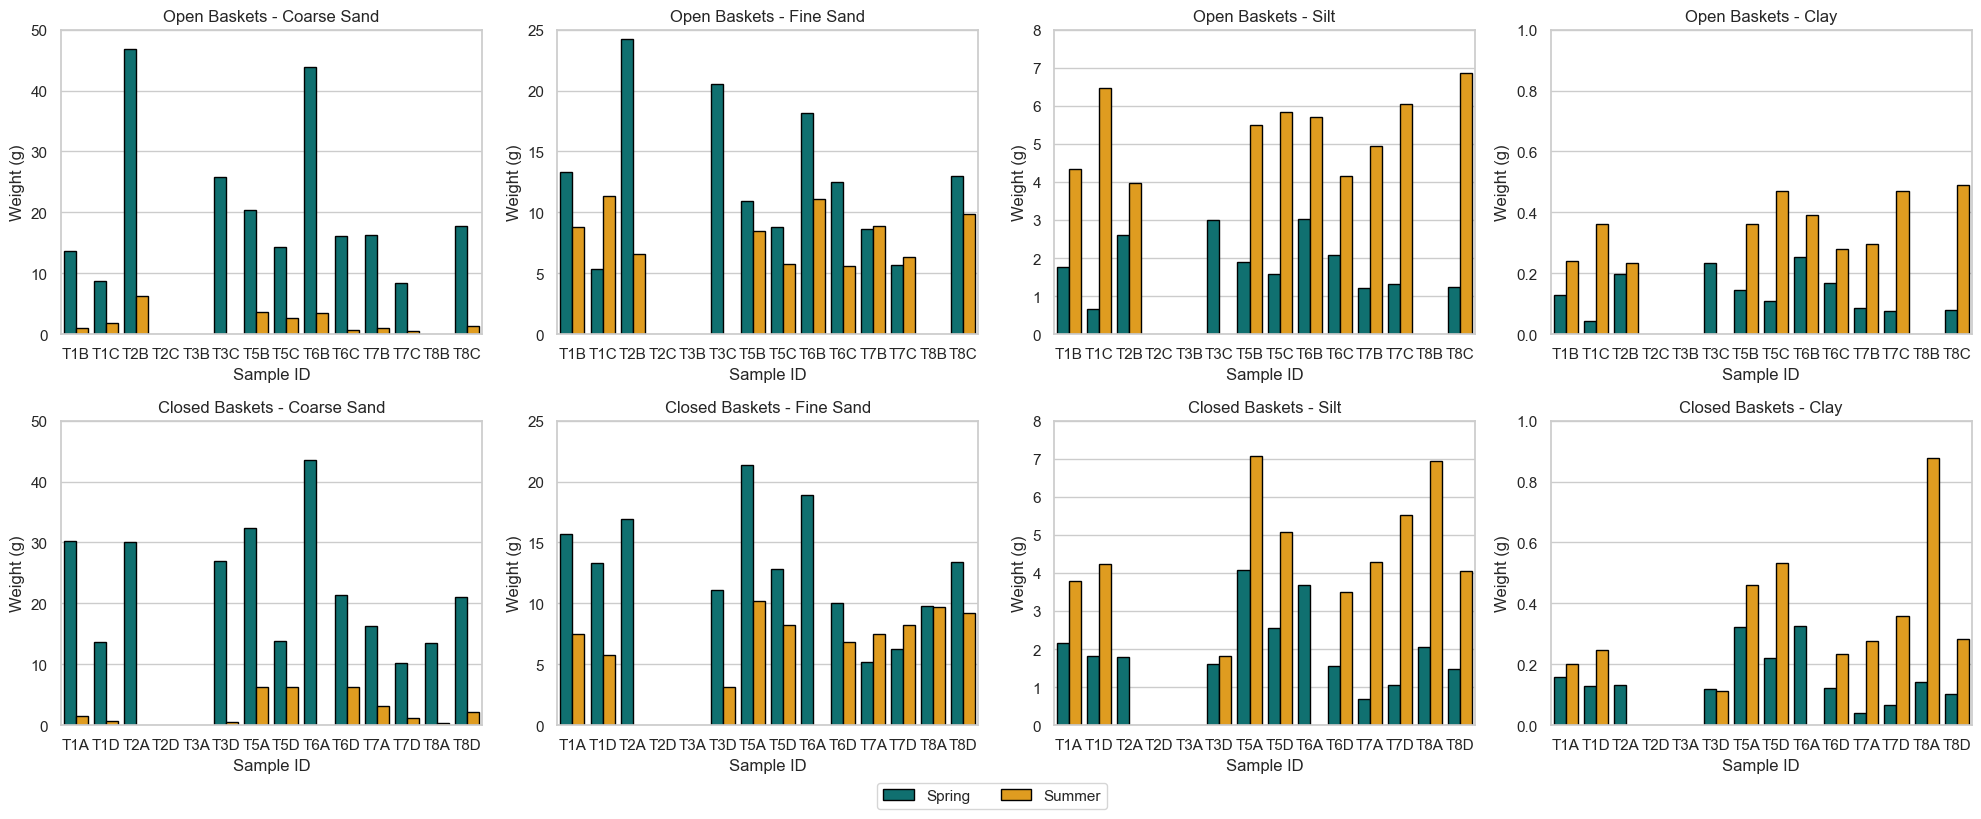

In [22]:
# create open and closed bar plots using subplots
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# coarse sand
sns.barplot(data=open_CS, x='Sample', y='Weight', hue='season', 
            ax=axs[0, 0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0, 0].set_title('Open Baskets - Coarse Sand')
axs[0, 0].set_ylim(0, 50)
axs[0, 0].set_ylabel('Weight (g)')
axs[0, 0].set_xlabel('Sample ID')
axs[0, 0].legend_.remove()
sns.barplot(data=closed_CS, x='Sample', y='Weight', hue='season', 
            ax=axs[1, 0], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1, 0].set_title('Closed Baskets - Coarse Sand')
axs[1, 0].set_ylim(0, 50)
axs[1, 0].set_ylabel('Weight (g)')
axs[1, 0].set_xlabel('Sample ID')
axs[1, 0].legend_.remove() 

# fine sand
sns.barplot(data=open_FS, x='Sample', y='Weight', hue='season',
            ax=axs[0, 1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0, 1].set_title('Open Baskets - Fine Sand')
axs[0, 1].set_ylim(0, 25)
axs[0, 1].set_ylabel('Weight (g)')
axs[0, 1].set_xlabel('Sample ID')
axs[0, 1].legend_.remove()
sns.barplot(data=closed_FS, x='Sample', y='Weight', hue='season',
            ax=axs[1, 1], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1, 1].set_title('Closed Baskets - Fine Sand')
axs[1, 1].set_ylim(0, 25)
axs[1, 1].set_ylabel('Weight (g)')
axs[1, 1].set_xlabel('Sample ID')
axs[1, 1].legend_.remove()

# silt
sns.barplot(data=open_S, x='Sample', y='Weight', hue='season',
            ax=axs[0, 2], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0, 2].set_title('Open Baskets - Silt')
axs[0, 2].set_ylim(0, 8)
axs[0, 2].set_ylabel('Weight (g)')
axs[0, 2].set_xlabel('Sample ID')
axs[0, 2].legend_.remove()
sns.barplot(data=closed_S, x='Sample', y='Weight', hue='season',
            ax=axs[1, 2], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1, 2].set_title('Closed Baskets - Silt')
axs[1, 2].set_ylim(0, 8)
axs[1, 2].set_ylabel('Weight (g)')
axs[1, 2].set_xlabel('Sample ID')
axs[1, 2].legend_.remove()

# clay
sns.barplot(data=open_C, x='Sample', y='Weight', hue='season',
            ax=axs[0, 3], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[0, 3].set_title('Open Baskets - Clay')
axs[0, 3].set_ylim(0, 1)
axs[0, 3].set_ylabel('Weight (g)')
axs[0, 3].set_xlabel('Sample ID')
axs[0, 3].legend_.remove()
sns.barplot(data=closed_C, x='Sample', y='Weight', hue='season',
            ax=axs[1, 3], palette={'Spring': 'teal', 'Summer': 'orange'}, edgecolor='black')
axs[1, 3].set_title('Closed Baskets - Clay')
axs[1, 3].set_ylim(0, 1)
axs[1, 3].set_ylabel('Weight (g)')
axs[1, 3].set_xlabel('Sample ID')
axs[1, 3].legend_.remove()

# add a single legend for both plots
handles, labels = axs[0,0].get_legend_handles_labels()  # get legend info from the first plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

# adjust layout and save the figure
plt.tight_layout()  # Leave space for the legend at the bottom
plt.show()

## Main Bar Plot

Need to combine in order to represent three baskets (both open and closed)

In [ ]:
coarse_sand = pd.concat([spring_CS, summer_CS], ignore_index=True)
fine_sand = pd.concat([spring_FS, summer_FS], ignore_index=True)
silt = pd.concat([spring_S, summer_S], ignore_index=True)
clay = pd.concat([spring_C, summer_C], ignore_index=True)
total_weights = pd.concat([spring_weights, summer_weights], ignore_index=True)

# normalize Sample IDs to the same format used in plotting (e.g., T7D -> T7-D).
def normalize_sample_id(s):
    s = str(s).strip().upper().replace(' ', '')
    return pd.Series([s]).str.replace(r'^(T\d+)([A-D])$', r'\1-\2', regex=True).iat[0]

for df in [coarse_sand, fine_sand, silt, clay, total_weights]:
    df['Sample'] = df['Sample'].apply(normalize_sample_id)

target_samples = ['T7-D', 'T7-B', 'T8-C', 'T8-D', 'T5-A', 'T5-B']

summary_cs = coarse_sand[coarse_sand['Sample'].isin(target_samples)]
summary_fs = fine_sand[fine_sand['Sample'].isin(target_samples)]
summary_s = silt[silt['Sample'].isin(target_samples)]
summary_c = clay[clay['Sample'].isin(target_samples)]
summary_weights = total_weights[total_weights['Sample'].isin(target_samples)]

Primary (Total Weights)

<Figure size 500x500 with 0 Axes>

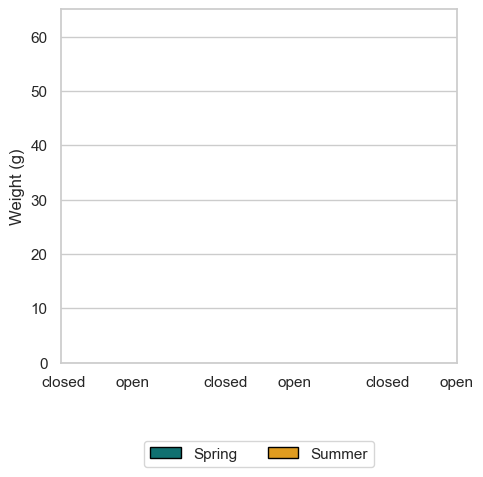

In [ ]:
labels = ['closed\n', 'open\n', 'closed\n', 'open\n', 'closed\n', 'open\n']
sample_order = ['T7-D', 'T7-B', 'T8-C', 'T8-D', 'T5-A', 'T5-B']

# spacing
group_gap = 1.3
pair_gap = 0.45
base = []
x = 0.0
for i in range(len(sample_order)):
    base.append(x)
    x += group_gap
    if (i + 1) % 2 == 0:
        x += pair_gap

bar_w = 0.55
offset = {'Spring': -bar_w/2, 'Summer': bar_w/2}
palette = {'Spring': '#107070', 'Summer': '#df9c20'}

fig, ax = plt.subplots(figsize=(5, 5))
for season in ['Spring', 'Summer']:
    vals = (summary_weights[summary_weights['season'] == season]
            .drop_duplicates(subset=['Sample'], keep='first')
            .set_index('Sample')
            .reindex(sample_order)['Weight']
            .fillna(0))
    ax.bar([b + offset[season] for b in base], vals, width=bar_w,
           color=palette[season], edgecolor='black', label=season)

ax.set_ylim(0, 65)
ax.set_ylabel('Weight (g)')
ax.set_xlabel('')
ax.set_xticks(base)
ax.set_xticklabels(labels)
ax.xaxis.grid(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

plt.tight_layout()
plt.show()

Secondary (Weights by Grain Size)

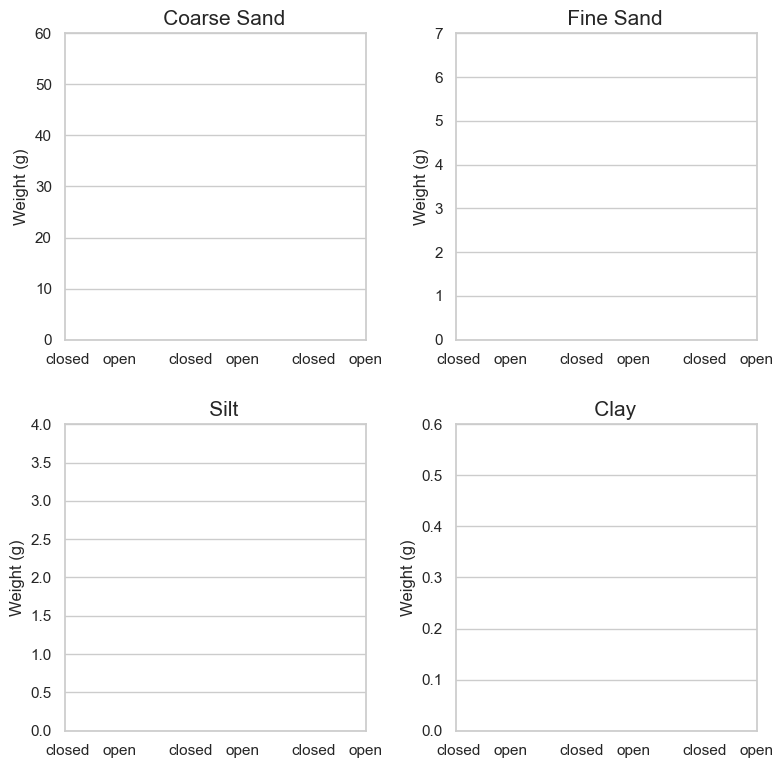

In [29]:
teal = '#107070'
orange = '#df9c20'

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
sns.set_theme(style="whitegrid")
labels = ['closed\n', 'open\n', 'closed\n', 'open\n', 'closed\n', 'open\n']
sample_order = ['T7-D', 'T7-B', 'T8-C', 'T8-D', 'T5-A', 'T5-B'] # define the desired order of the samples

# base positions for each sample
group_gap = 1.3          # gap between sample groups within a pair
pair_gap = 0.45         # extra gap after every 2 groups
base = []
x = 0.0
for i in range(len(sample_order)):
    base.append(x)
    x += group_gap
    if (i + 1) % 2 == 0:
        x += pair_gap

bar_w = 0.5
offset = {'Spring': -bar_w/2, 'Summer': bar_w/2}
palette = {'Spring': teal, 'Summer': orange}

def plot_pairgap(ax, df, ylim, title):
    for season in ['Spring', 'Summer']:
        vals = (df[df['season'] == season]
                .set_index('Sample')
                .reindex(sample_order)['Weight'])
        ax.bar([b + offset[season] for b in base], vals, width=bar_w,
               color=palette[season], edgecolor='black', label=season)
    ax.set_title(title, size=15)
    ax.set_ylim(*ylim)
    ax.set_ylabel('Weight (g)')
    ax.set_xlabel('')
    ax.set_xticks(base)
    ax.xaxis.grid(False)
    ax.set_xticklabels(labels)
    ax.legend_.remove() if ax.legend_ else None

plot_pairgap(axs[0,0], summary_cs, (0, 70), '   Coarse Sand')
axs[0,0].set_ylim(0, 60)
plot_pairgap(axs[0,1], summary_fs, (0, 6),  '   Fine Sand')
axs[0,1].set_ylim(0, 7)
plot_pairgap(axs[1,0], summary_s,  (0, 3.5),'   Silt')
axs[1,0].set_ylim(0, 4)
plot_pairgap(axs[1,1], summary_c,  (0, 0.5),'   Clay')
axs[1,1].set_ylim(0, 0.6)


# Set alpha for lightslategray bars in all subplots
for ax in axs.flat:
    for patch in ax.patches:
        # Convert patch color to RGB for comparison, ignoring alpha
        patch_color = mcolors.to_rgb(patch.get_facecolor())
        lightslategray_rgb = mcolors.to_rgb('lightslategray')
        
        if patch_color == lightslategray_rgb:
            # Set the color with a new alpha
            patch.set_facecolor((119/255, 136/255, 153/255, 0.01))  # lightslategray with alpha 0.1

plt.tight_layout()
#plt.savefig('plots/sizes_basket_weights_barplots_V7.jpg', dpi=1000, bbox_inches='tight')
plt.show()

Plotting by different seasons

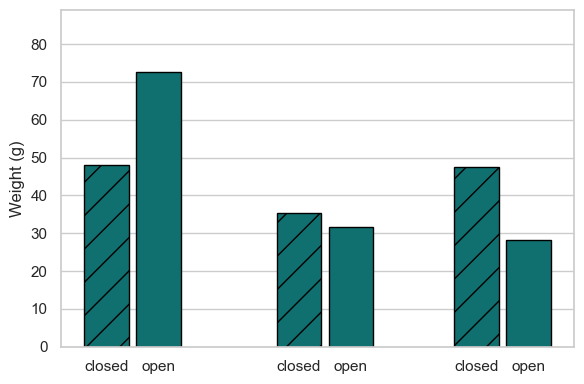

In [13]:
spring_weights = total_weights[total_weights['Sample'].str.startswith(('T2-A', 'T2-B', 'T8-D', 'T8-C', 'T1-A', 'T1-B'))]
labels = ['closed\n', 'open\n', 'closed\n', 'open\n', 'closed\n', 'open\n']
# define the desired order of the samples
sample_order = ['T2-A', 'T2-B', 'T8-D', 'T8-C', 'T1-A', 'T1-B']
# filter by season
spring_data = total_weights[(total_weights['season'] == 'Spring') &
    (total_weights['Sample'].isin(sample_order))][['Sample', 'Weight']]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 4))

# define positions for bars
x_positions = [0.15, 0.5, 1.45, 1.8, 2.65, 3]
bar_width = 0.3
teal = '#107070'

# order the data according to sample_order
ordered_spring = spring_data.set_index('Sample').loc[sample_order, 'Weight'].values
bars = ax.bar(x_positions, ordered_spring, width=bar_width, color=teal, edgecolor='black')
# hatch the closed traps
for bar, sample in zip(bars, sample_order):
    if sample.endswith(('A', 'D')):
        bar.set_hatch('/')

ax.set_ylabel('Weight (g)')
ax.set_xlabel('')
ax.set_ylim(0, 89)
#ax.set_title('Spring')
ax.xaxis.grid(False)

# Set x-tick positions at the center of each pair
ax.set_xticks(x_positions)
ax.set_xticklabels(['closed', 'open', 'closed', 'open', 'closed', 'open'])
plt.tight_layout()
plt.savefig('plots/total_weights_spring_individal_hatches_wide.jpg', dpi=1000, bbox_inches='tight')
plt.show()      

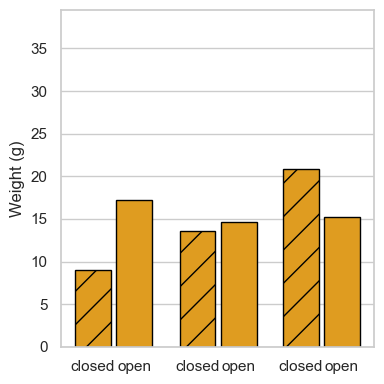

In [14]:
# summer samples and ordering
sample_order = ['T1-D', 'T1-C', 'T8-D', 'T8-C', 'T5-A', 'T5-B']
summer_data = total_weights[
    (total_weights['season'] == 'Summer') &
    (total_weights['Sample'].isin(sample_order))
][['Sample','Weight']]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(4, 4))

# define positions for bars (pairs closer together)
x_positions = [0.0, 0.52, 1.32, 1.84, 2.62, 3.14]
bar_width = 0.45
orange = "#DF9C20"

# plot bars
bars = ax.bar(x_positions, summer_data.set_index('Sample').loc[sample_order, 'Weight'].values, width=bar_width, color=orange, edgecolor='black')
ax.set_ylabel('Weight (g)')
ax.set_xlabel('')
ax.set_ylim(0, 39.5)  
ax.xaxis.grid(False)

for bar, sample in zip(bars, sample_order):
    if sample.endswith(('A', 'D')):
        bar.set_hatch('/')

# Labels under each bar based on ID suffix
labels = [('closed' if s.endswith(('A','D')) else 'open') for s in sample_order]
ax.set_xticks(x_positions)
ax.set_xticklabels(labels)

plt.tight_layout()
plt.savefig('plots/total_weights_summer_individual_hatches_narrow.jpg', dpi=1000, bbox_inches='tight')
plt.show()